In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

print("✅ Libraries Imported Successfully")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries Imported Successfully


In [2]:
DATA_PATH = Path("../../Dataset/processed")

orders = pd.read_csv(
    DATA_PATH / "orders_final_cleaned.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [3]:
print("Rows :", orders.shape[0])
print("Columns :", orders.shape[1])

Rows : 98232
Columns : 13


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,Tuesday,13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,Wednesday,9
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,Saturday,13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,Tuesday,2


In [5]:
orders.tail()



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days
98227,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,2017,3,9,Thursday,8
98228,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2018,2,6,Tuesday,22
98229,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,2017,8,27,Sunday,24
98230,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018,1,8,Monday,17
98231,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03,2018,3,8,Thursday,7


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98232 entries, 0 to 98231
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98232 non-null  object        
 1   customer_id                    98232 non-null  object        
 2   order_status                   98232 non-null  object        
 3   order_purchase_timestamp       98232 non-null  datetime64[ns]
 4   order_approved_at              98232 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98232 non-null  datetime64[ns]
 6   order_delivered_customer_date  98232 non-null  datetime64[ns]
 7   order_estimated_delivery_date  98232 non-null  datetime64[ns]
 8   Purchase Year                  98232 non-null  int64         
 9   Purchase Month                 98232 non-null  int64         
 10  Purchase Day                   98232 non-null  int64         
 11  Purchase Weekda

In [7]:
missing = orders.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

In [8]:
print("Duplicate Rows :", orders.duplicated().sum())

Duplicate Rows : 0


In [9]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
Purchase Year                             int64
Purchase Month                            int64
Purchase Day                              int64
Purchase Weekday                         object
Delivery Days                             int64
dtype: object

In [10]:
orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days
count,98232,98232,98232,98232,98232,98232,98232,98232,98232.000000,98232.000000,98232.000000,98232,98232.000000
unique,98232,98232,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monday,NaN
freq,1,1,96471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15987,NaN
mean,NaN,NaN,NaN,2017-12-30 13:04:22.725344256,2017-12-30 23:27:17.088596224,2018-01-05 06:06:51.487193344,2018-01-15 18:08:31.452734464,2018-01-23 07:58:33.804056064,2017.537686,6.031008,15.509661,NaN,15.746956
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,2016.000000,1.000000,1.000000,NaN,0.000000
25%,NaN,NaN,NaN,2017-09-11 14:15:11.249999872,2017-09-11 23:25:17,2017-09-18 16:21:37,2017-09-27 17:40:39.249999872,2017-10-02 00:00:00,2017.000000,3.000000,8.000000,NaN,6.000000
50%,NaN,NaN,NaN,2018-01-18 09:11:54,2018-01-18 13:12:59,2018-01-24 18:21:33.500000,2018-02-05 18:07:57.500000,2018-02-14 00:00:00,2018.000000,6.000000,15.000000,NaN,10.000000
75%,NaN,NaN,NaN,2018-05-04 08:40:40.500000,2018-05-04 15:10:22,2018-05-08 14:38:00,2018-05-16 19:16:47,2018-05-25 00:00:00,2018.000000,8.000000,23.000000,NaN,16.000000
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,2018.000000,12.000000,31.000000,NaN,692.000000


In [11]:
orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Delivery Days
count,98232,98232,98232,98232,98232,98232.000000,98232.000000,98232.000000,98232.000000
mean,2017-12-30 13:04:22.725344256,2017-12-30 23:27:17.088596224,2018-01-05 06:06:51.487193344,2018-01-15 18:08:31.452734464,2018-01-23 07:58:33.804056064,2017.537686,6.031008,15.509661,15.746956
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,2016.000000,1.000000,1.000000,0.000000
25%,2017-09-11 14:15:11.249999872,2017-09-11 23:25:17,2017-09-18 16:21:37,2017-09-27 17:40:39.249999872,2017-10-02 00:00:00,2017.000000,3.000000,8.000000,6.000000
50%,2018-01-18 09:11:54,2018-01-18 13:12:59,2018-01-24 18:21:33.500000,2018-02-05 18:07:57.500000,2018-02-14 00:00:00,2018.000000,6.000000,15.000000,10.000000
75%,2018-05-04 08:40:40.500000,2018-05-04 15:10:22,2018-05-08 14:38:00,2018-05-16 19:16:47,2018-05-25 00:00:00,2018.000000,8.000000,23.000000,16.000000
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,2018.000000,12.000000,31.000000,692.000000
std,NaN,NaN,NaN,NaN,NaN,0.505253,3.232126,8.666395,35.030407


In [12]:
orders.describe(include="object")

,order_id,customer_id,order_status,Purchase Weekday
count,98232,98232,98232,98232
unique,98232,98232,8,7
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,Monday
freq,1,1,96471,15987


In [13]:
orders["order_status"].value_counts()

order_status
delivered      96471
shipped          604
unavailable      423
canceled         311
processing       212
invoiced         205
created            4
approved           2
Name: count, dtype: int64

In [14]:
orders["order_status"].value_counts(normalize=True)*100

order_status
delivered      98.207305
shipped         0.614871
unavailable     0.430613
canceled        0.316597
processing      0.215816
invoiced        0.208690
created         0.004072
approved        0.002036
Name: proportion, dtype: float64

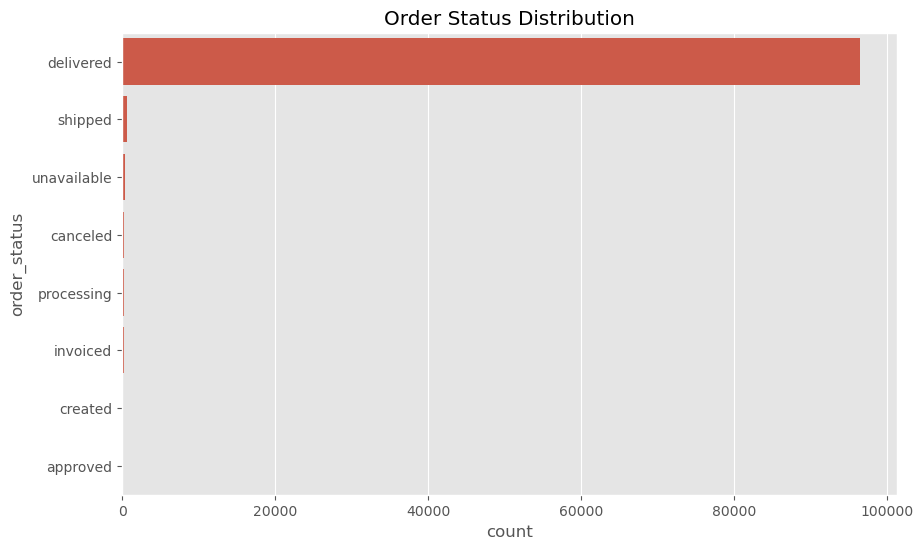

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="order_status",
    data=orders,
    order=orders["order_status"].value_counts().index
)

plt.title("Order Status Distribution")

plt.show()

In [16]:
orders["Purchase Year"].value_counts().sort_index()

Purchase Year
2016      329
2017    44756
2018    53147
Name: count, dtype: int64

In [17]:
orders["Purchase Month"].value_counts().sort_index()

Purchase Month
1      7963
2      8405
3      9766
4      9238
5     10472
6      9341
7     10175
8     10670
9      4243
10     4910
11     7451
12     5598
Name: count, dtype: int64

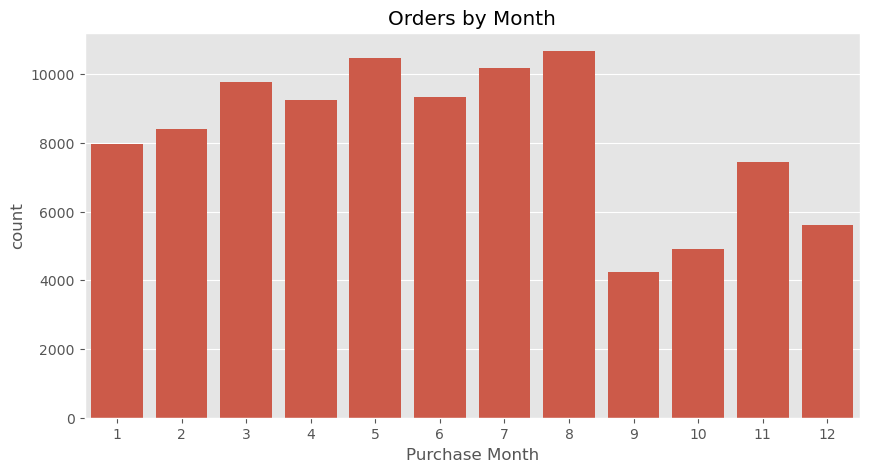

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Purchase Month",
    data=orders
)

plt.title("Orders by Month")

plt.show()

In [19]:
orders["Purchase Weekday"].value_counts()

Purchase Weekday
Monday       15987
Tuesday      15772
Wednesday    15360
Thursday     14578
Friday       13938
Sunday       11843
Saturday     10754
Name: count, dtype: int64

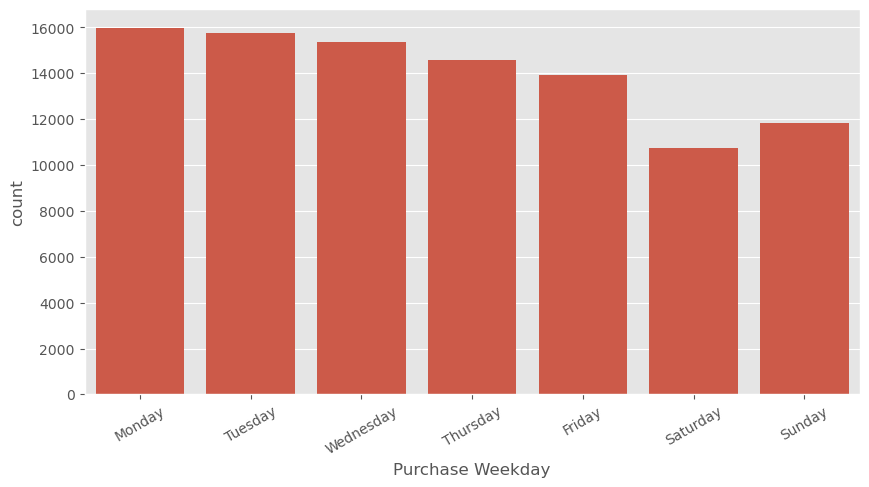

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Purchase Weekday",
    data=orders,
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]
)

plt.xticks(rotation=30)

plt.show()

In [21]:
orders["Delivery Days"].describe()

count    98232.000000
mean        15.746956
std         35.030407
min          0.000000
25%          6.000000
50%         10.000000
75%         16.000000
max        692.000000
Name: Delivery Days, dtype: float64

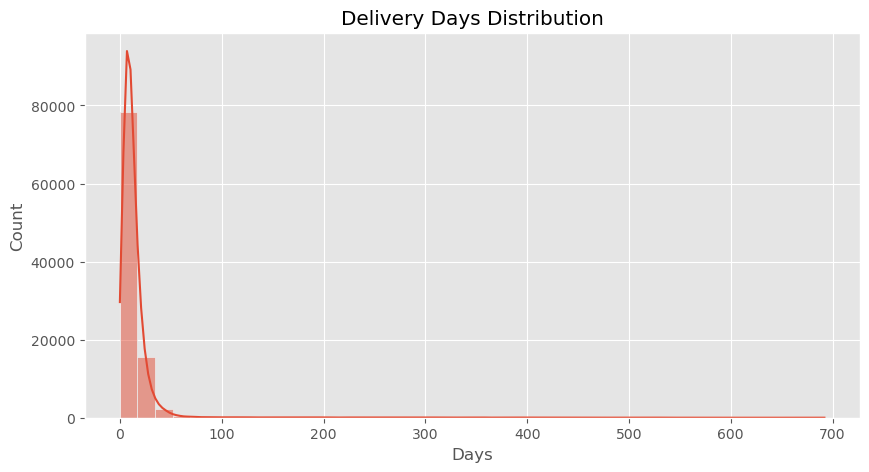

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["Delivery Days"],
    bins=40,
    kde=True
)

plt.title("Delivery Days Distribution")

plt.xlabel("Days")

plt.show()

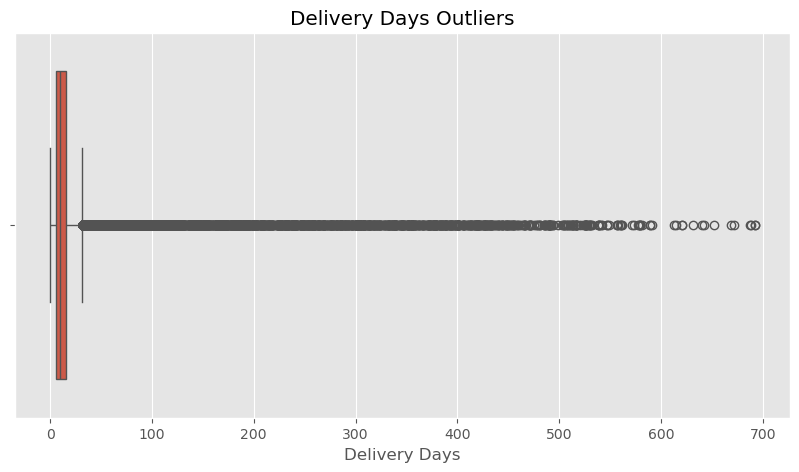

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=orders["Delivery Days"]
)

plt.title("Delivery Days Outliers")

plt.show()

In [24]:
orders.nsmallest(
    10,
    "Delivery Days"
)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,2018-08-02 10:35:00,2018-08-03 19:28:47,2018-08-21,2018,8,3,Friday,0
390,38c1e3d4ed6a13cd0cf612d4c09766e9,18c934f4cdc994cd04eb13bce3f47a18,delivered,2018-02-02 15:26:38,2018-02-02 16:00:16,2018-02-03 01:18:26,2018-02-03 15:05:56,2018-02-20,2018,2,2,Friday,0
726,d3ca7b82c922817b06e5ca21165c5ea2,d23df2c6c3e51d875f458d123b2b3c90,delivered,2017-11-16 13:54:08,2017-11-16 14:08:23,2017-11-16 20:56:53,2017-11-17 13:49:40,2017-11-29,2017,11,16,Thursday,0
4909,bcd65d5c97ac448bb3efc90b759909fd,b6ba3ad41b033a7f107aabad3dabff93,unavailable,2018-07-20 16:24:23,2018-07-20 16:44:16,2018-07-18 15:14:00,2018-07-20 17:48:34,2018-08-01,2018,7,20,Friday,0
11443,f4dcd6f5120e9e46509a58be9e7462f2,c61f5ec2a237a476d50b5194f90af516,shipped,2018-08-02 16:04:26,2018-08-03 02:50:36,2018-08-03 14:34:00,2018-08-02 17:28:42,2018-08-15,2018,8,2,Thursday,0
31142,1d893dd7ca5f77ebf5f59f0d2017eee0,b19da0df0271e8a3553e3670f86aeab5,delivered,2017-06-19 08:19:45,2017-06-19 08:30:20,2017-06-19 13:32:04,2017-06-19 21:07:52,2017-06-30,2017,6,19,Monday,0
37292,21a8ffca665bc7a1087d31751a7b7cbc,225aed9e773953084b09cf496c2be05a,delivered,2017-05-31 12:00:35,2017-05-31 13:07:28,2017-05-31 12:43:47,2017-06-01 10:28:24,2017-06-13,2017,5,31,Wednesday,0
38321,f3c6775ba3d2d9fe2826f93b71f12008,6aef84c09844a371d82a49152c550b95,delivered,2017-07-04 11:37:47,2017-07-04 11:50:21,2017-07-04 13:53:13,2017-07-05 08:09:26,2017-07-17,2017,7,4,Tuesday,0
41295,434cecee7d1a65fc65358a632b6f725f,922a46283625e9c096bfd998913c470c,delivered,2017-05-29 13:21:46,2017-05-29 13:30:24,2017-05-29 14:54:51,2017-05-30 08:06:56,2017-06-19,2017,5,29,Monday,0
43772,0538bda829ac14e64a201dc84fb1ba3b,84cb4824ee3f6d0c24b60d12a8e5bd00,shipped,2018-05-18 23:21:25,2018-05-21 18:35:58,2018-06-06 14:10:00,2018-05-19 17:32:26,2018-06-25,2018,5,18,Friday,0


In [25]:
orders.nlargest(
    10,
    "Delivery Days"
)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days
3022,ddaec6fff982b13e7e048b627a11d6da,68f4ad79cc0c2ad06e19088f5c00e9fa,canceled,2016-10-04 19:41:32,2016-10-04 19:41:32,2018-08-23 09:38:00,2018-08-28 14:58:51,2016-11-16,2016,10,4,Tuesday,692
69077,e04f1da1f48bf2bbffcf57b9824f76e1,0d00d77134cae4c58695086ad8d85100,invoiced,2016-10-05 13:22:20,2016-10-06 15:51:38,2018-08-21 14:39:00,2018-08-28 17:18:28,2016-11-29,2016,10,5,Wednesday,692
60081,3c3ca08854ca922fe8e9cedfd6841c8a,88c36fbd3df96094f90f0315e1d2dd90,unavailable,2016-10-08 12:13:38,2016-10-08 13:21:35,2018-08-15 11:55:00,2018-08-27 21:22:58,2016-11-30,2016,10,8,Saturday,688
29788,92d731517f17c26f16182d45498c4c3d,95c44daefa7bfb91c6bb0665a0cd22fc,canceled,2016-10-05 11:23:13,2016-10-05 11:23:13,2018-08-21 15:38:00,2018-08-23 23:48:32,2016-11-14,2016,10,5,Wednesday,687
76129,620b0acb9258b51defbc51804c5298d5,9012f48ac2c416c82819101da4e4b75e,canceled,2016-10-04 11:44:01,2016-10-05 08:45:09,2018-07-31 13:00:00,2018-08-07 19:28:50,2016-12-06,2016,10,4,Tuesday,672
10196,c4e980a1d822db426982878b3cfdda6e,88dc22aad9cf20898eb3780977173dc5,invoiced,2016-10-08 22:06:28,2016-10-09 15:15:10,2018-08-01 13:36:00,2018-08-09 02:16:35,2016-12-12,2016,10,8,Saturday,669
4487,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,2016-10-18 13:14:51,2018-06-19 20:56:30,2016-10-20,2016,9,4,Sunday,652
13499,35b8e54d765e6b217e2dc5ab34f6b323,1aaa5eaa9dd9bafb385aadc1930ef8e4,invoiced,2016-10-06 12:23:07,2016-10-07 03:10:10,2018-07-04 11:28:00,2018-07-10 16:56:45,2016-11-30,2016,10,6,Thursday,642
87996,bfd31c6f76ff82a41e7beb05565aec4d,6c65055adfbc0007dbb4c5a22ea5ba8c,canceled,2016-10-04 14:51:15,2016-10-06 15:56:40,2018-07-03 15:23:00,2018-07-06 17:32:30,2016-12-14,2016,10,4,Tuesday,640
54537,c549f0d88f33bfe43351b893f1fb55ac,ea26950075411d4c3569a71853ee7388,canceled,2016-10-06 13:21:05,2016-10-06 13:21:05,2018-06-28 14:01:00,2018-06-29 17:41:39,2016-11-16,2016,10,6,Thursday,631


In [26]:
print("Average Delivery Days :", round(orders["Delivery Days"].mean(),2))

Average Delivery Days : 15.75


In [27]:
print("Median Delivery Days :", orders["Delivery Days"].median())

Median Delivery Days : 10.0


In [28]:
monthly_orders = (
    orders
    .groupby("Purchase Month")
    .size()
)

monthly_orders

Purchase Month
1      7963
2      8405
3      9766
4      9238
5     10472
6      9341
7     10175
8     10670
9      4243
10     4910
11     7451
12     5598
dtype: int64

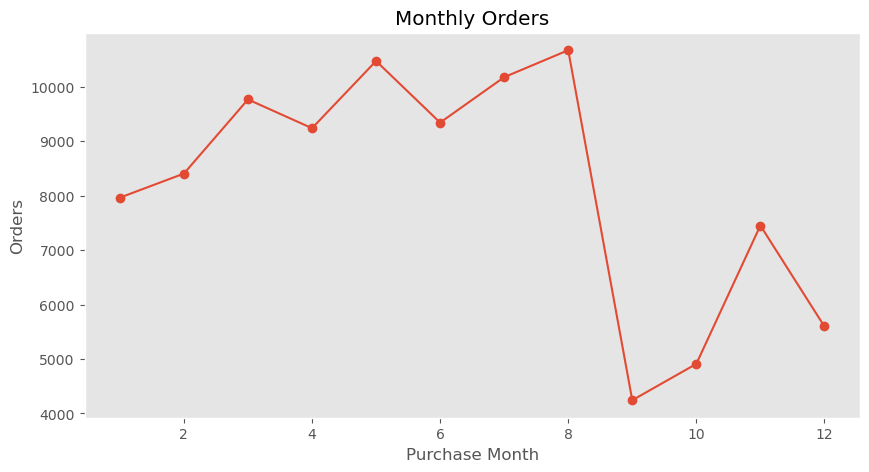

In [29]:
plt.figure(figsize=(10,5))

monthly_orders.plot(
    marker="o"
)

plt.title("Monthly Orders")

plt.ylabel("Orders")

plt.grid()

plt.show()

In [30]:
monthly_delivery = (
    orders
    .groupby("Purchase Month")["Delivery Days"]
    .mean()
)

monthly_delivery

Purchase Month
1     16.600779
2     21.249018
3     19.985767
4     14.947283
5     14.643621
6     12.458302
7     12.456609
8     10.752015
9     15.676880
10    20.308554
11    17.682593
12    16.724723
Name: Delivery Days, dtype: float64

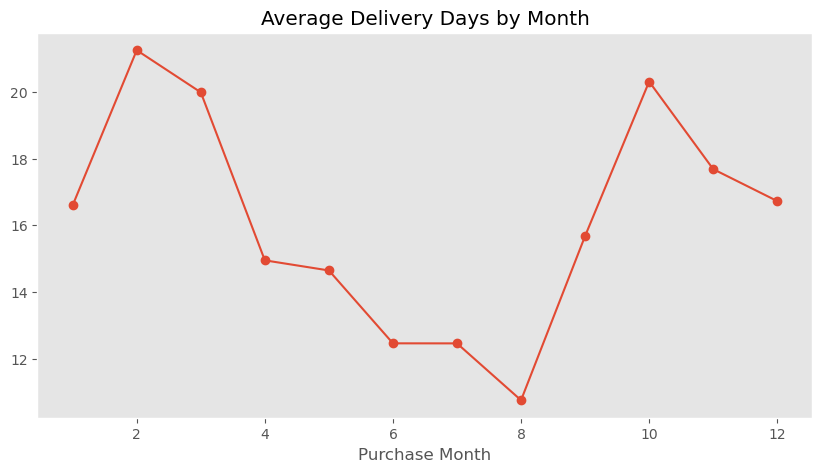

In [31]:
plt.figure(figsize=(10,5))

monthly_delivery.plot(
    marker="o"
)

plt.title("Average Delivery Days by Month")

plt.grid()

plt.show()

In [32]:
weekday_orders = (
    orders["Purchase Weekday"]
    .value_counts()
)

weekday_orders

Purchase Weekday
Monday       15987
Tuesday      15772
Wednesday    15360
Thursday     14578
Friday       13938
Sunday       11843
Saturday     10754
Name: count, dtype: int64

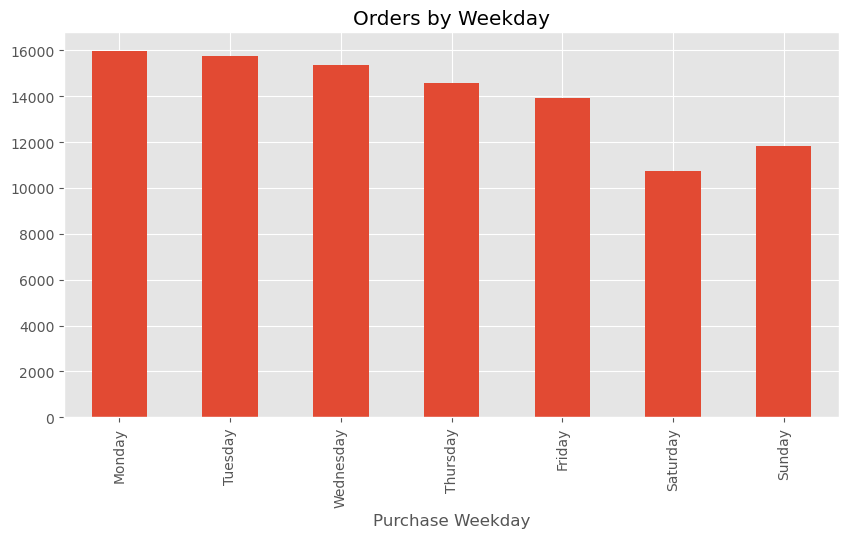

In [33]:
plt.figure(figsize=(10,5))

weekday_orders.loc[
[
"Monday",
"Tuesday",
"Wednesday",
"Thursday",
"Friday",
"Saturday",
"Sunday"
]
].plot(kind="bar")

plt.title("Orders by Weekday")

plt.show()

In [34]:
orders.select_dtypes(
    include=["int64","float64"]
).columns

Index(['Purchase Year', 'Purchase Month', 'Purchase Day', 'Delivery Days'], dtype='object')

In [35]:
corr = orders.select_dtypes(
    include=["int64","float64"]
).corr()

corr

,Purchase Year,Purchase Month,Purchase Day,Delivery Days
Purchase Year,1.000000,-0.549111,-0.043472,-0.125693
Purchase Month,-0.549111,1.000000,0.001561,-0.023670
Purchase Day,-0.043472,0.001561,1.000000,-0.011436
Delivery Days,-0.125693,-0.023670,-0.011436,1.000000


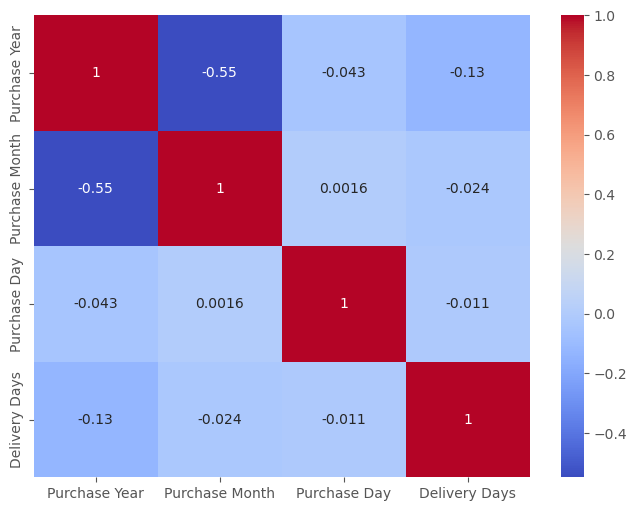

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [37]:
orders["order_purchase_timestamp"].dt.date.value_counts().head(10)

order_purchase_timestamp
2017-11-24    1167
2017-11-25     496
2017-11-27     400
2017-11-26     389
2017-11-28     379
2018-05-07     365
2018-08-06     363
2018-05-14     359
2018-08-07     354
2018-05-16     353
Name: count, dtype: int64

In [38]:
daily_orders = (
    orders
    .groupby(
        orders["order_purchase_timestamp"].dt.date
    )
    .size()
)

daily_orders.head()

order_purchase_timestamp
2016-09-04    1
2016-09-05    1
2016-09-13    1
2016-09-15    1
2016-10-02    1
dtype: int64

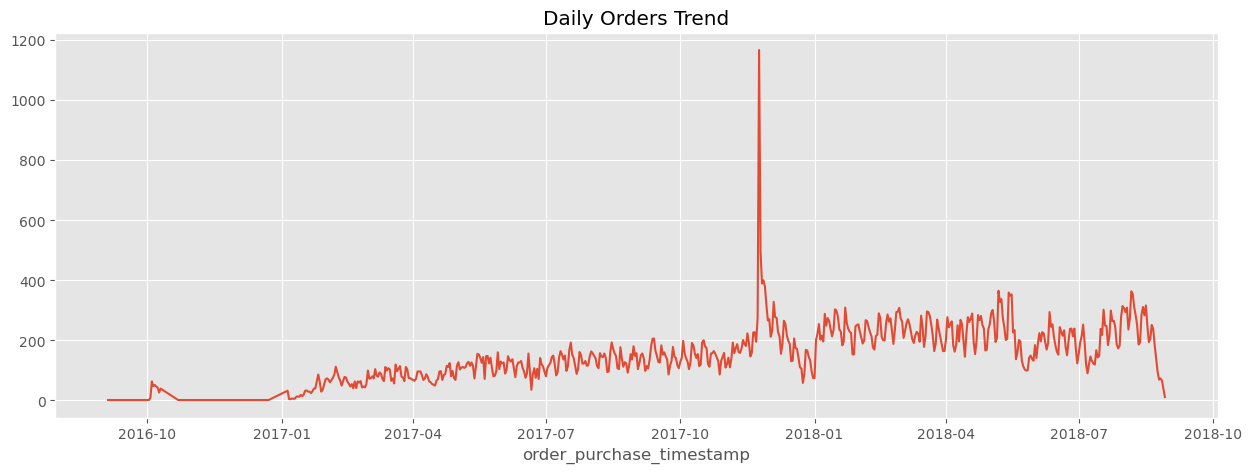

In [39]:
plt.figure(figsize=(15,5))

daily_orders.plot()

plt.title("Daily Orders Trend")

plt.show()

In [40]:
print("="*60)

print("Total Orders :", len(orders))

print("Average Delivery Days :", round(orders["Delivery Days"].mean(),2))

print("Median Delivery Days :", round(orders["Delivery Days"].median(),2))

print("Most Common Order Status :")

print(orders["order_status"].mode()[0])

print("="*60)

Total Orders : 98232
Average Delivery Days : 15.75
Median Delivery Days : 10.0
Most Common Order Status :
delivered


In [41]:
orders.groupby("Purchase Year").size()


Purchase Year
2016      329
2017    44756
2018    53147
dtype: int64

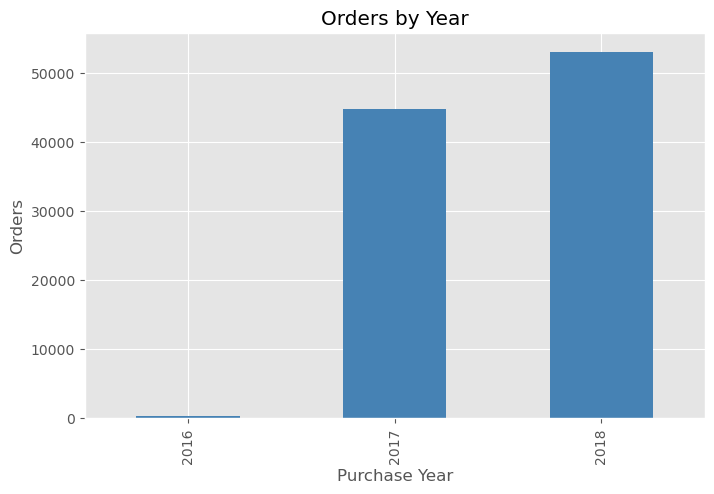

In [42]:
plt.figure(figsize=(8,5))

orders.groupby("Purchase Year").size().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Orders by Year")
plt.ylabel("Orders")

plt.show()

In [43]:
orders.groupby("Purchase Weekday")["Delivery Days"].mean()

Purchase Weekday
Friday       16.558617
Monday       15.299556
Saturday     16.738609
Sunday       14.904078
Thursday     15.904719
Tuesday      15.078684
Wednesday    15.968164
Name: Delivery Days, dtype: float64

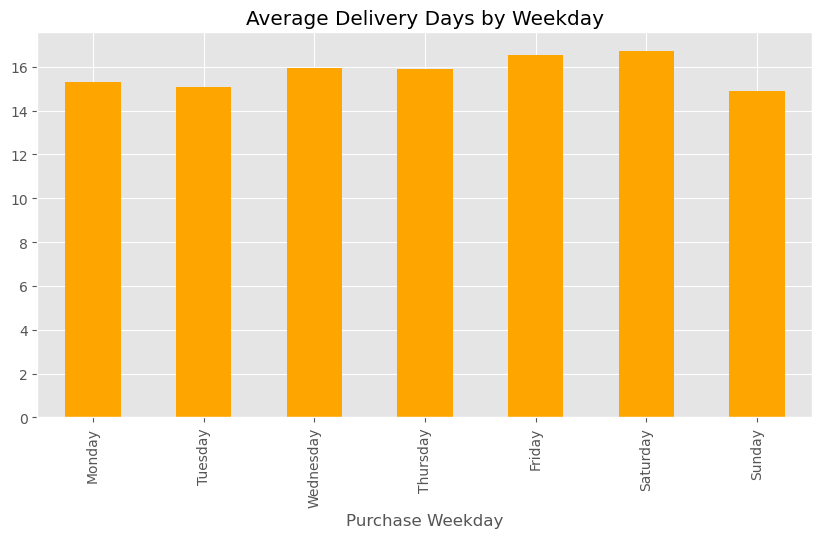

In [44]:
weekday_delivery = orders.groupby("Purchase Weekday")["Delivery Days"].mean()

weekday_delivery = weekday_delivery.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(10,5))

weekday_delivery.plot(
    kind="bar",
    color="orange"
)

plt.title("Average Delivery Days by Weekday")

plt.show()

In [45]:
orders.nlargest(
    10,
    "Delivery Days"
)[
[
"order_id",
"Delivery Days",
"order_status"
]
]

,order_id,Delivery Days,order_status
3022,ddaec6fff982b13e7e048b627a11d6da,692,canceled
69077,e04f1da1f48bf2bbffcf57b9824f76e1,692,invoiced
60081,3c3ca08854ca922fe8e9cedfd6841c8a,688,unavailable
29788,92d731517f17c26f16182d45498c4c3d,687,canceled
76129,620b0acb9258b51defbc51804c5298d5,672,canceled
10196,c4e980a1d822db426982878b3cfdda6e,669,invoiced
4487,2e7a8482f6fb09756ca50c10d7bfc047,652,shipped
13499,35b8e54d765e6b217e2dc5ab34f6b323,642,invoiced
87996,bfd31c6f76ff82a41e7beb05565aec4d,640,canceled
54537,c549f0d88f33bfe43351b893f1fb55ac,631,canceled


In [46]:
orders.nsmallest(
    10,
    "Delivery Days"
)[
[
"order_id",
"Delivery Days",
"order_status"
]
]

,order_id,Delivery Days,order_status
103,0760a852e4e9d89eb77bf631eaaf1c84,0,invoiced
390,38c1e3d4ed6a13cd0cf612d4c09766e9,0,delivered
726,d3ca7b82c922817b06e5ca21165c5ea2,0,delivered
4909,bcd65d5c97ac448bb3efc90b759909fd,0,unavailable
11443,f4dcd6f5120e9e46509a58be9e7462f2,0,shipped
31142,1d893dd7ca5f77ebf5f59f0d2017eee0,0,delivered
37292,21a8ffca665bc7a1087d31751a7b7cbc,0,delivered
38321,f3c6775ba3d2d9fe2826f93b71f12008,0,delivered
41295,434cecee7d1a65fc65358a632b6f725f,0,delivered
43772,0538bda829ac14e64a201dc84fb1ba3b,0,shipped


In [47]:
orders[
orders["Delivery Days"] < 0
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days


In [48]:
orders["Delivery Days"].value_counts().head(20)

Delivery Days
7     7660
6     6810
8     6756
9     6044
5     5816
10    5627
11    5116
4     4832
12    4677
13    4382
3     3853
14    3841
15    3178
2     3174
16    2641
17    2368
18    2176
19    1820
20    1727
1     1576
Name: count, dtype: int64

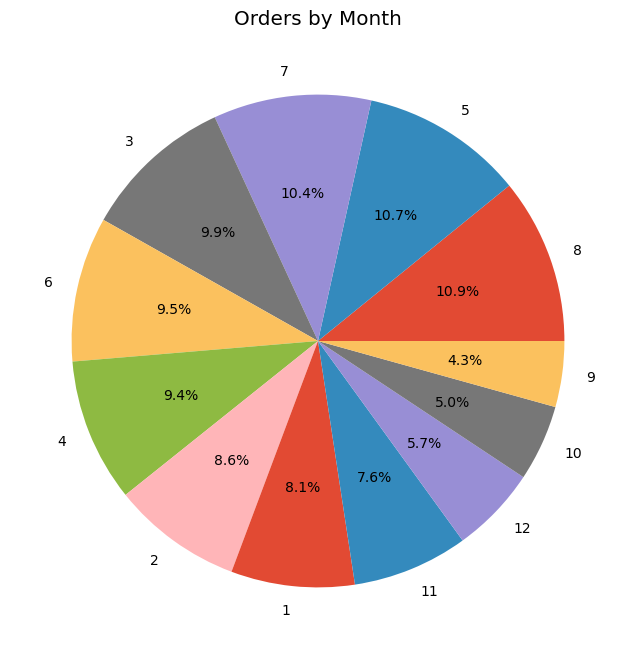

In [49]:
orders["Purchase Month"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.ylabel("")

plt.title("Orders by Month")

plt.show()

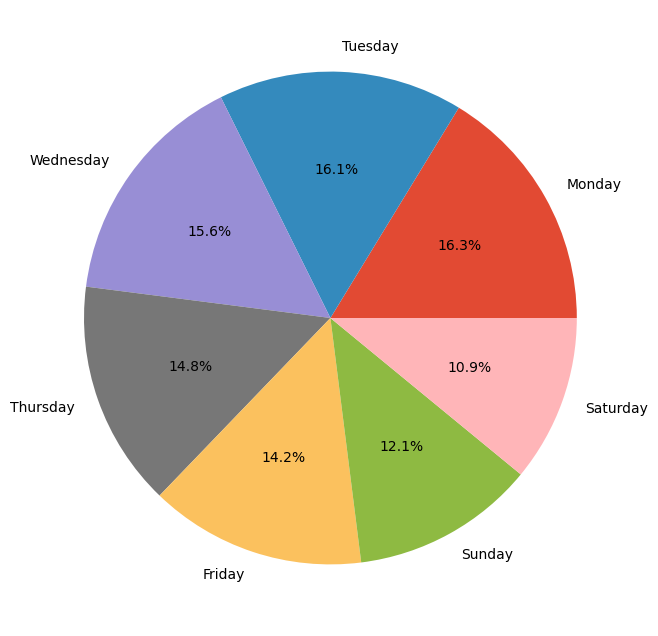

In [50]:
orders["Purchase Weekday"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.ylabel("")

plt.show()

In [51]:
orders.select_dtypes(
    include=["int64","float64"]
).head()

,Purchase Year,Purchase Month,Purchase Day,Delivery Days
0,2017,10,2,8
1,2018,7,24,13
2,2018,8,8,9
3,2017,11,18,13
4,2018,2,13,2


In [52]:
orders.mean(
    numeric_only=True
)

Purchase Year     2017.537686
Purchase Month       6.031008
Purchase Day        15.509661
Delivery Days       15.746956
dtype: float64

In [53]:
orders.median(
    numeric_only=True
)

Purchase Year     2018.0
Purchase Month       6.0
Purchase Day        15.0
Delivery Days       10.0
dtype: float64

In [54]:
orders.std(
    numeric_only=True
)

Purchase Year      0.505253
Purchase Month     3.232126
Purchase Day       8.666395
Delivery Days     35.030407
dtype: float64

In [55]:
orders.var(
    numeric_only=True
)

Purchase Year        0.255281
Purchase Month      10.446636
Purchase Day        75.106401
Delivery Days     1227.129390
dtype: float64

In [56]:
orders.quantile(
    [0.25,0.50,0.75],
    numeric_only=True
)

,Purchase Year,Purchase Month,Purchase Day,Delivery Days
0.25,2017.0,3.0,8.0,6.0
0.50,2018.0,6.0,15.0,10.0
0.75,2018.0,8.0,23.0,16.0


In [57]:
orders.skew(
    numeric_only=True
)

Purchase Year    -0.229040
Purchase Month    0.207455
Purchase Day      0.023316
Delivery Days     9.868104
dtype: float64

In [58]:
orders.kurt(
    numeric_only=True
)

Purchase Year      -1.749058
Purchase Month     -0.977608
Purchase Day       -1.176678
Delivery Days     114.916619
dtype: float64

In [59]:
orders.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Day,Purchase Weekday,Delivery Days
94001,077a77e315e3b317121a0af9962e122b,6457e3fd7f768aef7be536207c963d9f,delivered,2018-05-11 10:35:33,2018-05-11 10:58:06,2018-05-14 15:21:00,2018-05-21 23:44:22,2018-05-25,2018,5,11,Friday,10
70502,b7e56bc4544b2d0098a4571a45eea22c,2aa80ed97e46eea9e72138907912799f,delivered,2018-07-09 15:15:04,2018-07-09 15:25:13,2018-07-26 15:10:00,2018-07-30 17:24:53,2018-08-03,2018,7,9,Monday,21
23953,b6e4cfebbca461e11b3f453db216b3e2,5fba8d7ca09f3a20f54ce1b72302f95c,delivered,2018-04-30 14:14:00,2018-04-30 14:32:33,2018-05-02 14:03:00,2018-05-07 13:24:44,2018-05-23,2018,4,30,Monday,6
7654,21b966a378471db65c18fa4ca20d6800,f253cdb921536ec2a9ff9a11cab13aea,delivered,2018-08-21 20:34:12,2018-08-21 20:50:15,2018-08-22 15:21:00,2018-08-27 17:32:06,2018-09-05,2018,8,21,Tuesday,5
9695,1431b547a5eddb3dbc9adaef89b9e5f9,fe91e175a31617a8a51b8097e2c53dbe,delivered,2017-05-17 09:03:36,2017-05-18 02:25:42,2017-05-19 10:57:43,2017-05-29 12:23:54,2017-06-12,2017,5,17,Wednesday,12
96604,7520a4f97d875cef28e46e627eaaf336,da80034e1558c53729291348af036338,delivered,2017-08-26 21:03:40,2017-08-26 21:24:10,2017-08-29 21:11:34,2017-10-14 15:35:42,2017-09-21,2017,8,26,Saturday,48
53963,068c06f0ea08ab32e127f87aafaa834d,1633693027f6a28a4f6ee559c2950e37,delivered,2017-09-12 17:48:50,2017-09-12 18:04:35,2017-09-18 21:45:49,2017-09-26 15:55:05,2017-09-29,2017,9,12,Tuesday,13
26825,130e5f15b505062879273e8f199441d1,241a20babe281dff9201cd9abc43b96a,delivered,2018-05-16 12:09:43,2018-05-16 12:39:15,2018-05-17 13:51:00,2018-05-22 00:04:16,2018-05-30,2018,5,16,Wednesday,5
77237,15abee31fcd5f096e6eb7c555eb3fca3,2732a3f9aa9dab45d4b7a1c35b90bb7d,delivered,2017-05-07 19:37:27,2017-05-09 09:25:41,2017-05-16 11:26:52,2017-05-17 15:38:06,2017-05-19,2017,5,7,Sunday,9
72495,0cd60792eb628e2fe7f77456cc67c4db,56dae8b071493b64e4712e339cc50c06,delivered,2018-02-12 20:29:57,2018-02-12 20:47:34,2018-02-14 16:28:34,2018-02-28 19:23:54,2018-03-06,2018,2,12,Monday,15


In [60]:
orders.to_csv(
    "../../Dataset/processed/orders_eda.csv",
    index=False
)

print("="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("Dataset Saved")
print("="*60)

EDA COMPLETED SUCCESSFULLY
Dataset Saved
